In [1]:
# Imports
from scipy.io import loadmat
import pandas as pd
import numpy as np
import plotly.express as px
import torch.nn as nn
import torch
import itertools
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

cuda
True
NVIDIA GeForce RTX 4070 Ti SUPER


In [3]:
data = loadmat('Xtrain.mat')

In [4]:
def data_cleaning(df: pd.DataFrame) -> pd.DataFrame:
    normalized = df/255
    return normalized
    
def slices(s: pd.Series, slice_length) -> tuple[pd.Series, pd.Series]:
    slices = [window for window in s.rolling(window=slice_length+1)]
    res = [(slc.iloc[:-1], slc.iloc[-1]) for slc in slices[slice_length:]]
    return res

def cv_split(X: np.ndarray, Y: np.ndarray, n_splits=5, gap=0, overlap=False) -> list[tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, int, int]]:
    split_size = len(X) // n_splits
    splits = []
    for i in range(n_splits):
        start = i * split_size
        end = (i + 1) * split_size if i < n_splits - 1 else len(X)

        train_left_end = max(0, start - gap)
        train_right_start = min(len(X), end + gap)

        X_train = np.concatenate((X[:train_left_end], X[train_right_start:]), axis=0)
        Y_train = np.concatenate((Y[:train_left_end], Y[train_right_start:]), axis=0)
        X_val = X[start:end]
        Y_val = Y[start:end]
        splits.append((X_train, Y_train, X_val, Y_val, start, end))
        if i < n_splits - 1 and overlap:
            intermediate_start = (end - start) // 2 + start
            intermediate_end = intermediate_start + split_size

            train_left_end = max(0, intermediate_start - gap)
            train_right_start = min(len(X), intermediate_end + gap)

            X_train = np.concatenate((X[:train_left_end], X[train_right_start:]), axis=0)
            Y_train = np.concatenate((Y[:train_left_end], Y[train_right_start:]), axis=0)
            X_val = X[intermediate_start:intermediate_end]
            Y_val = Y[intermediate_start:intermediate_end]
            splits.append((X_train, Y_train, X_val, Y_val, intermediate_start, intermediate_end))
    return splits

In [5]:
class BaselineNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, output_size=1):
        super().__init__()

        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size),
            nn.Sigmoid() # since we normalized the data to [0,1]
        )

    def forward(self, x):
        x = self.flatten(x)
        out = self.linear_relu_stack(x)

        return out

In [6]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True # needed because we have (batch_size, seq_len, 1). So batch size is given first
        )
        
        self.fc = nn.Linear(hidden_size, 1) # Connects final layer to output

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)

        # pass through model
        out, _ = self.lstm(x)

        # out contains hidden states for all timesteps:
        # shape: (batch_size, seq_len, hidden_size)
        
        # we only care about last timestep.
        out = out[:, -1, :] #takes last timestep
        out = self.fc(out) # gets prediction
        
        return out

In [7]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        
        self.lstm = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True # needed because we have (batch_size, seq_len, 1). So batch size is given first
        )
        
        self.fc = nn.Linear(hidden_size, 1) # Connects final layer to output

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)

        # pass through model
        out, _ = self.lstm(x)

        # out contains hidden states for all timesteps:
        # shape: (batch_size, seq_len, hidden_size)
        
        # we only care about last timestep.
        out = out[:, -1, :] #takes last timestep
        out = self.fc(out) # gets prediction
        
        return out

In [8]:
def train_model(X_train, Y_train, X_val, Y_val, seed, device, learning_rate, epochs, model_class, model_kwargs, noise):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = model_class(**model_kwargs).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=10,
        min_lr=1e-5
    )

    current_lr = optimizer.param_groups[0]['lr']

    for epoch in range(epochs):
        model.train()
        #train_loss_epoch = 0.0

        optimizer.zero_grad()
        noise = torch.randn_like(X_train) * noise # add noise, model learns to predict with imperfect inputs
        pred = model(X_train + noise)
        #pred = model(X_train)
        loss = criterion(pred, Y_train)
        loss.backward()
        optimizer.step()

        #train_loss_epoch += loss.item()

        #train_loss_epoch /= len(loader)

        # validation loss for scheduler
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, Y_val).item()

        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']

        #if new_lr != current_lr:
            #print(f"Learning rate reduced: {current_lr:.6f} -> {new_lr:.6f} in epoch {epoch}")

        current_lr = new_lr

    return model

In [9]:
def ensemble_recursive_predict(models, start_tensor, steps, device):
    window = start_tensor.clone().unsqueeze(0)
    preds = []

    for _ in range(steps):
        step_preds = []

        for model in models:
            with torch.no_grad():
                pred = model(window)
                step_preds.append(pred.item())

        avg_pred = np.mean(step_preds)
        preds.append(avg_pred)

        new_point = torch.tensor([[[avg_pred]]], dtype=torch.float32).to(device)
        window = torch.cat([window[:, 1:, :], new_point], dim=1)

    return np.array(preds)

In [ ]:
def run_model(config):
    model_class = config["model_class"]
    model_kwargs = config["model_kwargs"]
    epochs = config["epochs"]
    lr = config["lr"]
    noise = config["noise"]
    window_size_local = config["window"]
    name = config["name"]

    # create data
    series_full = pd.Series(data['Xtrain'].flatten())
    series_full = data_cleaning(series_full).values

    # build dataset using THAT window size
    df = pd.Series(data['Xtrain'].flatten())
    df = data_cleaning(df)

    X, Y = zip(*slices(df, window_size_local))
    X = np.array(X).reshape(-1, window_size_local, 1)
    Y = np.array(Y).reshape(-1, 1)

    fold_maes = []
    fold_preds = []
    fold_true = []

    for fold_idx, (X_train, Y_train, X_val, Y_val, val_start, val_end) in enumerate(cv_split(X, Y, n_splits=4, gap=window_size_local, overlap=True),start=1):

        X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
        Y_train = torch.tensor(Y_train, dtype=torch.float32).to(device)
        X_val   = torch.tensor(X_val, dtype=torch.float32).to(device)
        Y_val   = torch.tensor(Y_val, dtype=torch.float32).to(device)

        model = train_model(
            X_train, Y_train,
            X_val, Y_val,
            seed=1000,
            device=device,
            learning_rate=lr,
            epochs=epochs,
            model_class=model_class,
            model_kwargs=model_kwargs,
            noise=noise
        )

        # 200-step eval
        start_window = series_full[val_start:val_start + window_size_local]
        true_future = series_full[val_start + window_size_local: val_start + window_size_local + 200]

        start_tensor = torch.tensor(start_window.reshape(window_size_local, 1),dtype=torch.float32).to(device)

        preds = ensemble_recursive_predict([model], start_tensor, len(true_future), device)

        mae = mean_absolute_error(true_future, preds)

        fold_maes.append(mae)
        fold_preds.append(preds)
        fold_true.append(true_future)

    return {
        "name": name,
        "mae_mean": np.mean(fold_maes),
        "mae_std": np.std(fold_maes),
        "preds": fold_preds,
        "true": fold_true
    }

In [22]:
models_to_compare = [
    {
        "name": "LSTM",
        "model_class": LSTMModel,
        "model_kwargs": {"hidden_size": 32, "num_layers": 2},
        "epochs": 12500,
        "lr": 1e-2,
        "noise": 0.1,
        "window": 32
    },
    {
        "name": "GRU",
        "model_class": GRUModel,
        "model_kwargs": {"hidden_size": 64, "num_layers": 2},
        "epochs": 12500,
        "lr": 1e-2,
        "noise": 0.1,
        "window": 32
    },
    {
        "name": "Baseline",
        "model_class": BaselineNN,
        "model_kwargs": {"input_size": 16, "hidden_size": 32},
        "epochs": 12500,
        "lr": 1e-2,
        "noise": 0.0,
        "window": 16
    }
]

results = []

for config in models_to_compare:
    print(f"\nRunning model: {config['name']}")
    results.append(run_model(config))

for r in results:
    maes = []

    for preds, true in zip(r["preds"], r["true"]):
        maes.append(mean_absolute_error(true, preds))

    print(f"{r['name']}")
    print("MAE 200-step:", np.mean(maes), "+-", np.std(maes))


Running model: LSTM

Running model: GRU

Running model: Baseline
LSTM
MAE 200-step: 0.08017234792566601 +- 0.05736600954026862
GRU
MAE 200-step: 0.11949064094692217 +- 0.05127818437826315
Baseline
MAE 200-step: 0.12698088090667367 +- 0.058717460393807874



LSTM
200-step MAE: 0.0802 +- 0.0574
200-step MSE: 0.0217 +- 0.0209

GRU
200-step MAE: 0.1195 +- 0.0513
200-step MSE: 0.0403 +- 0.0269

Baseline
200-step MAE: 0.1270 +- 0.0587
200-step MSE: 0.0405 +- 0.0297


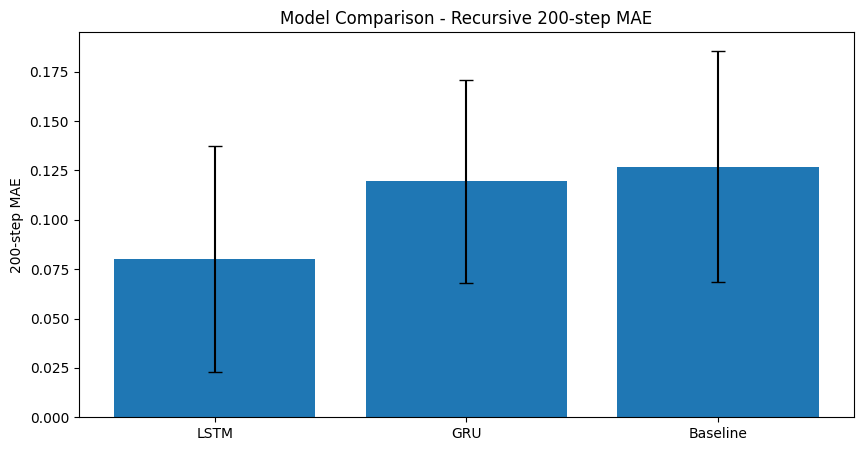

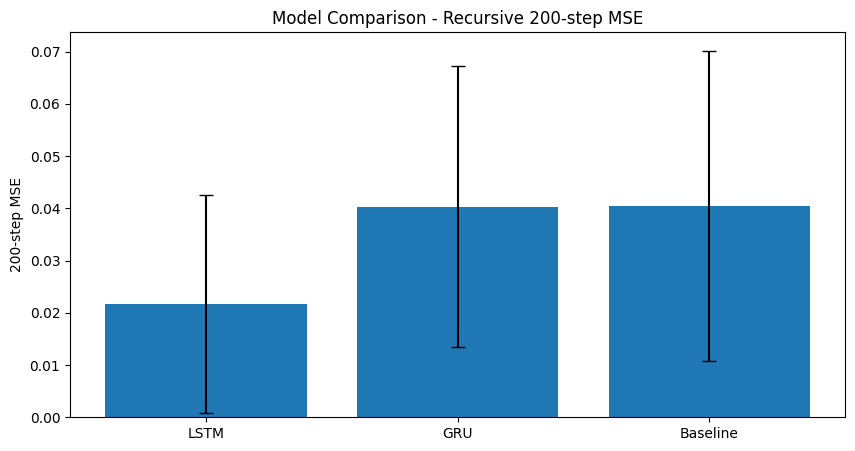

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

model_names = []
mae_means = []
mae_stds = []
mse_means = []
mse_stds = []

# calculate metrics
for r in results:

    maes = []
    mses = []

    for preds, true in zip(r["preds"], r["true"]):
        maes.append(mean_absolute_error(true, preds))
        mses.append(mean_squared_error(true, preds))

    model_names.append(r["name"])

    mae_means.append(np.mean(maes))
    mae_stds.append(np.std(maes))

    mse_means.append(np.mean(mses))
    mse_stds.append(np.std(mses))

    print(f"\n{r['name']}")
    print(f"200-step MAE: {np.mean(maes):.4f} +- {np.std(maes):.4f}")
    print(f"200-step MSE: {np.mean(mses):.4f} +- {np.std(mses):.4f}")


# -------------------------
# BAR PLOT: MAE
# -------------------------
plt.figure(figsize=(10, 5))

plt.bar(
    model_names,
    mae_means,
    yerr=mae_stds,
    capsize=5
)

plt.ylabel("200-step MAE")
plt.title("Model Comparison - Recursive 200-step MAE")

plt.show()


# -------------------------
# BAR PLOT: MSE
# -------------------------
plt.figure(figsize=(10, 5))

plt.bar(
    model_names,
    mse_means,
    yerr=mse_stds,
    capsize=5
)

plt.ylabel("200-step MSE")
plt.title("Model Comparison - Recursive 200-step MSE")

plt.show()